# План занятия

1. Жизненный цикл ML-модели
2. Обзор процесса деплоя модели
3. Сериализация/десериализация в Python: Pickle и Joblib
4. Сетевые протоколы и вопросы сетевого взаимодействия
5. Обзор основных фреймворков для создания веб-сервисов (Django, Flask, FastAPI)

# 1. Жизненный цикл ML-модели!

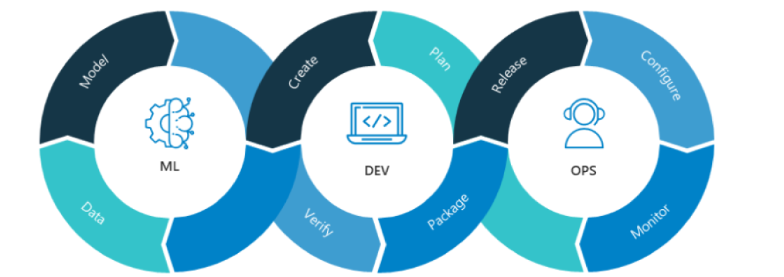
1. Data (Данные)
2. Model (Моделирование)
3. Create (Создание)
4. Verify (Проверка)
5. Plan (Планирование)
6. Package (Упаковка)
7. Release (Релиз)
8. Configure (Конфигурация)
9. Monitor (Мониторинг).

# 2. Обзор процесса деплоя модели

1. **Подготовка данных и модели к деплою**

До того, как модель может быть развернута, она должна пройти несколько ключевых этапов: сбор данных, их предобработка, обучение модели, тестирование и оценка качества.
Кроме того, модель должна быть зафиксирована в виде артефакта, который можно будет переносить и запускать в рабочей среде.

2. **Сериализация модели (Model Serialization)**

Сначала необходимо сериализовать (сохранить) модель в файл, чтобы потом можно было легко загружать её в продакшн для использования.
Наиболее распространенные форматы сериализации в Python:
- Pickle: основной формат для сохранения объектов в Python.
- Joblib: предназначен для сохранения моделей машинного обучения и других объектов больших объемов данных.

### Пример использования pickle для сериализации модели

In [1]:
import pickle
from sklearn.ensemble import RandomForestClassifier

# Обучаем модель
model = RandomForestClassifier()
model.fit(X_train, y_train)

# Сериализация модели
with open("model.pkl", "wb") as f:
    pickle.dump(model, f)

# Загрузка модели для использования в продакшн
with open("model.pkl", "rb") as f:
    loaded_model = pickle.load(f)

# Использование загруженной модели для предсказаний
prediction = loaded_model.predict(X_test)

NameError: name 'X_train' is not defined

### Joblib используется для более крупных объектов, например, если модель использует большие массивы данных.

In [ ]:
from joblib import dump, load

# Сохранение модели
dump(model, 'model.joblib')

# Загрузка модели
loaded_model = load('model.joblib')

3. **Создание API для модели**

Чтобы модель могла взаимодействовать с внешними системами, нужно создать REST API, через которое пользователи или другие приложения смогут отправлять данные для предсказаний.
В Python наиболее популярные инструменты для создания API:
- Flask: легковесный и простой веб-фреймворк.
- FastAPI: современный асинхронный фреймворк с автоматической документацией

### Пример создания простого REST API на Flask

In [ ]:
from flask import Flask, request, jsonify
import pickle

app = Flask(__name__)

# Загрузка модели
with open('model.pkl', 'rb') as f:
    model = pickle.load(f)

@app.route('/predict', methods=['POST'])
def predict():
    data = request.get_json()  # Получаем данные из POST-запроса
    prediction = model.predict([data['features']])
    return jsonify({'prediction': prediction.tolist()})

if __name__ == "__main__":
    app.run(debug=True)

4. **Контейнеризация модели**

Docker позволяет упаковать модель, её зависимости и окружение в контейнер, чтобы она могла быть развернута где угодно.
В контейнере можно включить всё, что нужно для выполнения модели: Python, библиотеки, модель, API и т.д.

5. **CI/CD для автоматизации деплоя**

CI/CD (Continuous Integration / Continuous Deployment) — это практика автоматизации сборки, тестирования и деплоя приложений.
Используя такие инструменты, как GitLab CI, Jenkins, CircleCI, можно настроить автоматическое тестирование модели и её деплой при каждом обновлении кода.

6. **Мониторинг модели (Model Monitoring)**

После развертывания модели важно следить за её производительностью в реальном времени. Это включает:
Мониторинг метрик качества (точность, ошибка).
Отслеживание входных данных на предмет дрейфа данных (data drift).
Логирование всех запросов и предсказаний для анализа.
Можно использовать такие инструменты, как Prometheus и Grafana для мониторинга модели в реальном времени.

7. **Взаимодействие с облачными сервисами для деплоя**

Для масштабируемого деплоя модели можно использовать облачные сервисы, такие как AWS SageMaker, Google AI Platform, Azure ML.
Эти сервисы упрощают настройку деплоя и предоставляют инструменты для мониторинга, автоматического масштабирования и переобучения модели.

# 3. Сериализация/десериализация в Python: Pickle и Joblib

`Сериализация` — это процесс преобразования объекта (например, модели машинного обучения) в последовательность байтов, которую можно сохранить в файл или передать по сети.

`Десериализация` — это процесс обратного преобразования байтового потока в объект Python.

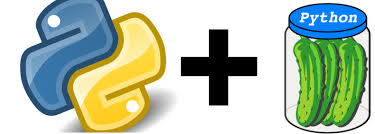

### 1. Pickle
`Pickle` — это стандартная библиотека Python для сериализации объектов. Она поддерживает сериализацию и десериализацию практически любых объектов Python: списков, словарей, классов, обученных моделей и даже функций.

**Особенности Pickle**
- Универсальность
- Нативная поддержка Python
- Поддержка пользовательских объектов

**Основные функции**
- `pickle.dump()` — сохраняет объект в файл.
- `pickle.load()` — загружает объект из файла.
- `pickle.dumps()` — преобразует объект в байтовую строку.
- `pickle.loads()` — восстанавливает объект из байтовой строки.

**Сохранение модели**

In [ ]:
import pickle
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_iris

# Загрузка данных и обучение модели
data = load_iris()
X, y = data.data, data.target
model = RandomForestClassifier()
model.fit(X, y)

# Сериализация модели в файл
with open("model.pkl", "wb") as file:
    pickle.dump(model, file)

**Загрузка модели**

In [ ]:
# Десериализация модели из файла
with open("model.pkl", "rb") as file:
    loaded_model = pickle.load(file)

# Использование загруженной модели
prediction = loaded_model.predict([[5.1, 3.5, 1.4, 0.2]])
print(f"Предсказание: {prediction}")

Здесь загружается модель из файла и используется для предсказания.

**Недостатки Pickle**
- Безопасность
- Совместимость версий
- Размер

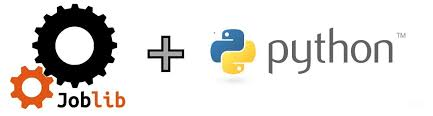

### 2. Joblib
`Joblib` — это библиотека Python, которая оптимизирована для сериализации объектов, содержащих большие массивы данных, такие как обученные модели машинного обучения, данные в формате NumPy или SciPy. Она работает быстрее и эффективнее, чем Pickle, когда речь идет о больших объектах, таких как модели машинного обучения.

**Особенности Joblib**
- Оптимизация для больших объектов
- Быстродействие
- Использование памяти

**Основные функции**
- `joblib.dump()` — сохраняет объект в файл (аналогично pickle.dump()).
- `joblib.load()` — загружает объект из файла (аналогично pickle.load()).

**Сохранение модели**

In [ ]:
from joblib import dump, load
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_iris

# Загрузка данных и обучение модели
data = load_iris()
X, y = data.data, data.target
model = RandomForestClassifier()
model.fit(X, y)

# Сериализация модели с использованием Joblib
dump(model, 'model.joblib')

**Загрузка модели**

In [ ]:
# Десериализация модели из файла
loaded_model = load('model.joblib')

# Использование загруженной модели
prediction = loaded_model.predict([[5.1, 3.5, 1.4, 0.2]])
print(f"Предсказание: {prediction}")

**Преимущества Joblib**

- Эффективность с большими данными 
- Сжатие данных

**Ограничения Joblib**

- Ограниченная совместимость с объектами Python
- Специфично для машинного обучения

| Характеристика          | Pickle                                     | Joblib                                   |
|-------------------------|--------------------------------------------|------------------------------------------|
| Универсальность         | Поддерживает любые объекты Python          | Ограничен объектами, связанными с ML/NumPy |
| Эффективность           | Медленнее на больших объектах              | Быстрее для больших массивов данных      |
| Использование памяти     | Сохраняет объекты целиком                  | Использует сжатие для уменьшения объема  |
| Использование в ML      | Меньше оптимизаций для ML                  | Оптимизирован для моделей ML            |
| Безопасность            | Уязвим к выполнению произвольного кода     | Аналогичная проблема безопасности        |
| Поддержка произвольных объектов | Поддерживает пользовательские классы и функции | Не поддерживает пользовательские классы или функции |


# 4. Сетевые протоколы и вопросы сетевого взаимодействия

**Основные сетевые протоколы и их функции**
1. `TCP/IP (Transmission Control Protocol/Internet Protocol)` — основа всего интернета и большинства современных сетей. TCP/IP обеспечивает надежную передачу данных с контролем ошибок.

- TCP — обеспечивает надежную передачу данных, создавая "сессии" между отправителем и получателем. Это протокол с установлением соединения, который гарантирует, что данные достигнут цели в правильном порядке.

- IP — отвечает за маршрутизацию данных между сетями. Это протокол без установления соединения, который работает с "пакетами" данных и передает их между узлами сети.

**Основные свойства TCP/IP**

- Надежность передачи данных.
- Доставка данных в правильном порядке.
- Контроль ошибок.

2. `HTTP (Hypertext Transfer Protocol)` — это основной протокол для передачи данных в интернете.

HTTP запрос поддерживает несколько методов (типов запросов), которые определяют действие, которое клиент хочет выполнить.
- `GET` — получение данных с сервера. Например, получение веб-страницы или данных от API.
- `POST` — отправка данных на сервер. Используется для отправки данных на сервер для обработки, например, для создания нового ресурса (например, добавление записи в базу данных).
- `PUT` — обновление существующего ресурса на сервере.
- `DELETE` — удаление ресурса на сервере.

3. `HTTPS (Hypertext Transfer Protocol Secure)` — это защищенная версия HTTP. Протокол HTTPS использует шифрование через SSL/TLS, чтобы обеспечить безопасную передачу данных.

**Основные свойства HTTPS**

- Шифрование данных
- Проверка подлинности
- Целостность данных.

4. `REST (Representational State Transfer)` — это архитектурный стиль взаимодействия между клиентом и сервером, который используется для создания веб-сервисов. 

**Принципы REST**

- Клиент-серверная архитектура
- Бесстатность (stateless)
- Кэширование
- Единый интерфейс (uniform interface)

**Преимущества REST API**

- Легкость разработки и использования.
- Поддержка многих языков программирования и фреймворков.
- Высокая масштабируемость.
- Простота интеграции с фронт-эндом и сторонними сервисами.

5. `WebSockets` — это протокол для взаимодействия в режиме реального времени. В отличие от HTTP, который основан на запросах (клиент запрашивает — сервер отвечает), WebSockets позволяют устанавливать двустороннюю связь между клиентом и сервером. Э

**Пример использования WebSockets**

- Клиент устанавливает соединение с сервером, и затем сервер может отправлять данные клиенту без необходимости ожидания запроса.
- Веб-приложения могут обновляться в реальном времени, например, при изменении состояния модели.

**Преимущества WebSockets**

- Низкие задержки в передаче данных.
- Возможность двусторонней связи.
- Идеален для приложений, работающих в режиме реального времени.

**Недостатки**

- Более сложная реализация, чем у HTTP/REST.
- Требует постоянного открытого соединения, что может быть ресурсозатратным.

6. `gRPC` — это современный протокол удаленного вызова процедур (Remote Procedure Call), разработанный Google. gRPC поддерживает асинхронные вызовы и использует формат сериализации данных Protocol Buffers (Protobuf), который значительно быстрее и эффективнее JSON или XML.

**Основные преимущества gRPC**

- Высокая производительность
- Поддержка множества языков
- Поддержка двунаправленных потоков

7. `MQTT (Message Queuing Telemetry Transport)` — легковесный протокол передачи сообщений, который используется для передачи данных в устройствах IoT (интернет вещей). Он работает поверх TCP/IP и обычно применяется в случаях, когда важны минимальные задержки и небольшое использование ресурсов.

### Пример создания простого API с использованием протокола HTTP и REST
Создадим простое API с использованием Flask, которое принимает запросы на предсказание модели

In [ ]:
from flask import Flask, request, jsonify
import pickle

app = Flask(__name__)

# Загрузка модели
with open('model.pkl', 'rb') as f:
    model = pickle.load(f)

@app.route('/predict', methods=['POST'])
def predict():
    data = request.get_json()
    features = data['features']
    prediction = model.predict([features])
    return jsonify({'prediction': prediction.tolist()})

if __name__ == '__main__':
    app.run(debug=True)

Это пример `REST API`, которое принимает `JSON` данные и возвращает предсказание модели. Клиент отправляет `POST` запрос с данными для предсказания, а сервер обрабатывает их и возвращает результат.

# 5. Обзор основных фреймворков для создания веб-сервисов (Django, Flask, FastAPI)

### 1. Flask
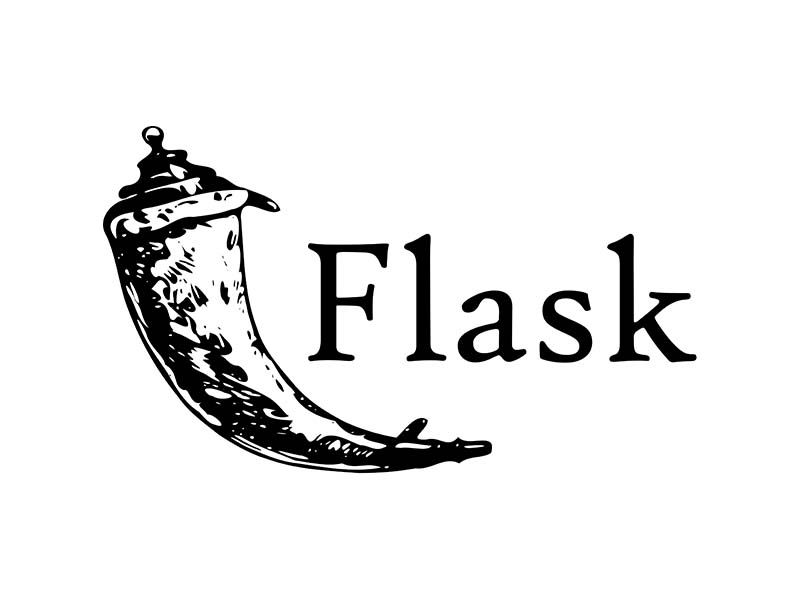

`Flask` — это микрофреймворк для веб-приложений, который разработан для простоты и легкости использования.

**Особенности Flask**
- Минимализм: 
- Гибкость: 
- Поддержка расширений: 

**Основные компоненты Flask**
- Маршрутизация (Routing)
- Шаблонизация (Templating)
- Поддержка JSON

### Пример простого веб-приложения на Flask

In [ ]:
from flask import Flask, jsonify, request

app = Flask(__name__)

# Пример маршрутизации
@app.route('/')
def hello_world():
    return 'Hello, World!'

# Пример REST API
@app.route('/predict', methods=['POST'])
def predict():
    data = request.json  # Получаем данные из POST запроса
    features = data['features']  # Извлекаем данные для предсказания
    # Пример: результат предсказания модели
    prediction = [1 if sum(features) > 10 else 0]
    return jsonify({'prediction': prediction})  # Возвращаем JSON ответ

if __name__ == '__main__':
    app.run(debug=True)


**Преимущества Flask**
- Простота
- Гибкость
- Легковесность

**Недостатки Flask**
- Меньше встроенных функций
- Масштабируемость

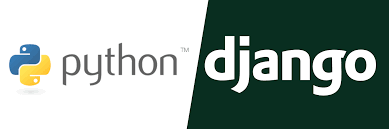
### 2. Django
`Django` — это фреймворк для веб-приложений, ориентированный на "все включено" (batteries-included). Он предоставляет все необходимые компоненты для создания полнофункциональных веб-приложений, таких как ORM для работы с базами данных, система аутентификации, админ-панель и многое другое. Django следует принципу DRY (Don't Repeat Yourself) и стремится к высокой скорости разработки.

**Особенности Django**
- "Все включено"
- Высокая скорость разработки
- Безопасность
- ORM (Object-Relational Mapping)

**Основные компоненты Django**
- ORM
- Система маршрутизации
- Шаблонизация
- Админ-панель

In [ ]:
# Установка Django
!pip install django

In [ ]:
# Допустим вы создадите в файле views.py приложения myapp
from django.http import JsonResponse
from django.views.decorators.csrf import csrf_exempt
import json

@csrf_exempt
def predict(request):
    if request.method == 'POST':
        data = json.loads(request.body)
        features = data['features']
        # Пример: результат предсказания модели
        prediction = [1 if sum(features) > 10 else 0]
        return JsonResponse({'prediction': prediction})

In [ ]:
# В другом файле вашего проекта, вы вызовет myapp из views
from django.urls import path
from myapp import views

urlpatterns = [
    path('predict/', views.predict),
]
# После этого запустите ваше приложение!

**Преимущества Django**
- Комплексность
- Безопасность
- Высокая производительность для разработки

**Недостатки Django**
- Избыточность для маленьких проектов
- Меньшая гибкость
- Ограниченная поддержка асинхронности

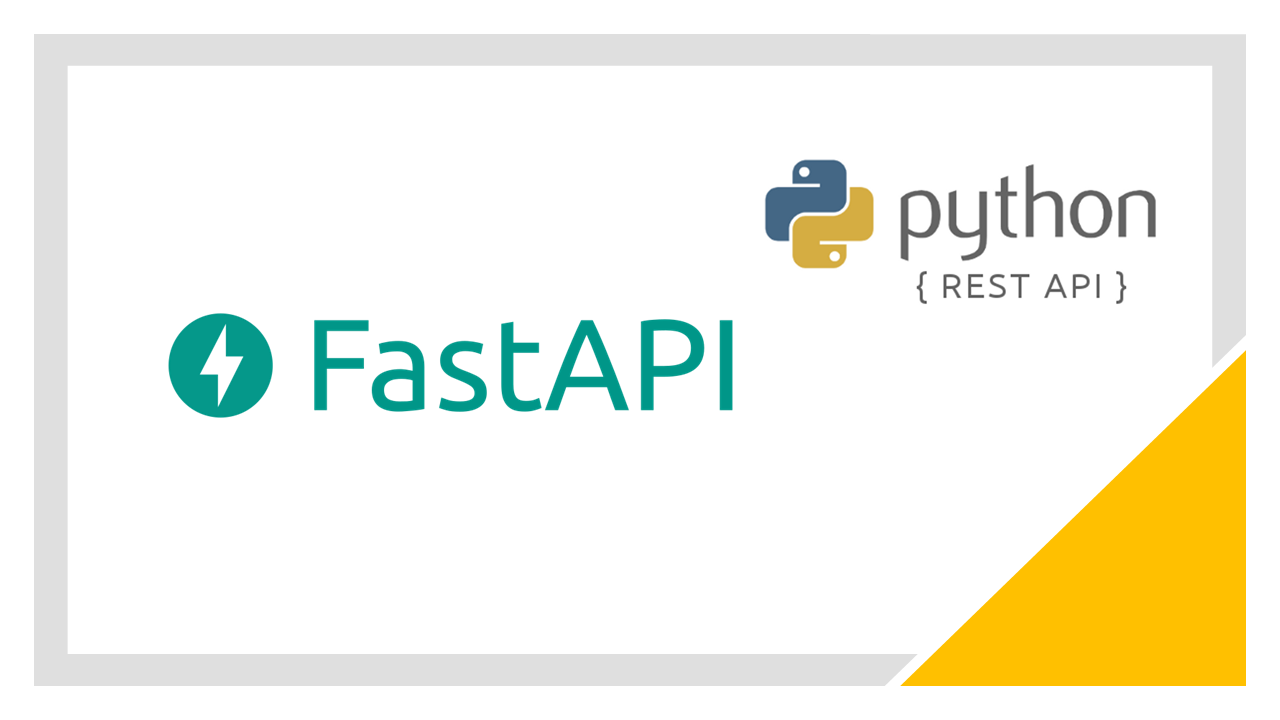
`FastAPI` — это современный фреймворк для создания API, ориентированный на высокую производительность и поддержку асинхронного программирования. FastAPI поддерживает спецификацию OpenAPI, что позволяет автоматически генерировать документацию для API. Он создан для работы с асинхронными запросами и идеально подходит для создания масштабируемых и высокопроизводительных приложений.

**Особенности FastAPI**
- Высокая производительность
- Автоматическая документация API
- Поддержка аннотаций типов
- Асинхронное программирование

In [ ]:
# Установка FastAPI
!pip install fastapi uvicorn

In [ ]:
from fastapi import FastAPI
from pydantic import BaseModel

app = FastAPI()

# Описание модели данных для предсказания
class PredictionInput(BaseModel):
    features: list[float]

@app.post("/predict")
async def predict(input_data: PredictionInput):
    features = input_data.features
    # Пример: результат предсказания модели
    prediction = [1 if sum(features) > 10 else 0]
    return {"prediction": prediction}

**Преимущества FastAPI**
- Асинхронность
- Высокая производительность 
- Автоматическая документация 
- Поддержка типов и валидации
**Недостатки FastAPI**
- Новизна
- Крутая кривая обучения

| Характеристика                     | Flask                              | Django                                 | FastAPI                                |
|-----------------------------------|------------------------------------|---------------------------------------|----------------------------------------|
| Тип фреймворка                    | Микрофреймворк                     | "Все включено"                        | Асинхронный, API-фреймворк             |
| Скорость разработки               | Высокая                            | Очень высокая (все готово "из коробки")| Очень высокая, особенно для API        |
| Асинхронность                     | Поддержка ограничена               | Ограниченная поддержка                | Полная поддержка асинхронности         |
| Масштабируемость                  | Подходит для небольших проектов    | Отлично подходит для крупных проектов | Отлично подходит для высоконагруженных API |
| Гибкость                          | Очень гибкий                       | Меньше гибкости                       | Гибкий и производительный              |
| Документация API                  | Требует ручной настройки           | Требует ручной настройки              | Автоматическая документация            |
| Поддержка встроенных компонентов  | Нет                                | ORM, админ-панель, аутентификация     | Нет встроенных компонентов             |
| Производительность                | Умеренная                          | Умеренная                             | Очень высокая                  arison.md
